# Backtest of **Inter-Day** Risk-Control Reweighting using Quantile Forecasts from a Bayesian Joint Quantile Time Series Model For Asset Returns

## Compare Risk Control Strategies

**The following analysis will compare a number of different strategies for controlling risk exposure to the S&P 500:**
1. Buying and holding the SPDR S&P 500 ETF (SPY) over the period
2. A baseline *inter*-day volatility control strategy using quantile forecasts from Bayesian Joint Quantile Time Series Model For Asset Returns as signals to reduce index exposure ahead of periods with large downside risk
3. A baseline *intra*day volatility control strategy using the S&P 500 Dynamic Intraday TCA Index Methodology (Controls index exposure through futures)
4. A refined *mixed frequency (inter and intra-day)* risk control strategy using the S&P 500 Intraday Edge Macro Indices methodology
5. A volatility control strategy using *intra*day quantile forecasts from the Bayesian Joint Quantile Time Series Model For Asset Returns


## Import packages

### Set up autoreloading

In [77]:
# set up automatic reloading of modules (so that we don't have to restart the kernel after editing a module)
#%load_ext autoreload
#%autoreload 2

### Import libraries


In [78]:
# Directory and file handling
import importlib  # Allows dynamic import of modules without having to restart the kernel
from pathlib import Path  # Object-oriented filesystem paths
import sys        # System-specific parameters and functions

# Data manipulation and analysis
import pandas as pd      # DataFrame and data analysis
import numpy as np       # Numerical operations
import openpyxl as px   # Excel file reading and writing
from scipy.io import loadmat # MATLAB file format for loading data
from itertools import product # For generating combinations of parameters
from dataclasses import replace # For working with dataclasses, allowing easy modification of config objects

# Plotting and visualization
import matplotlib.pyplot as plt           # Static plotting
import matplotlib.dates as mdates         # Date formatting for matplotlib
import matplotlib.colors as mcolors       # Color utilities for matplotlib for different line series colours
import plotly.graph_objs as go            # Interactive plotting
import plotly.io as pio                 # Plotly input/output utilities
from IPython.display import display # Display objects in Jupyter notebooks
# Grammar of graphics plotting (ggplot-style)
from plotnine import *                   # Main plotnine API for ggplot-style plotting
from plotnine.scales import scale_x_date # For date scaling on x-axis in plotnine

# Warnings control
import warnings  # Warning control
from plotnine.exceptions import PlotnineWarning


### Import Custom Packages

In [79]:
# import custom function under ../src/stats_utils
# first, add the parent directory to sys.path [will be useful later]
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Plotting

import src.stats_utils.dash_timeseries_app as dta

# Statistics and performance calculation
import src.stats_utils.strategies as st
import src.stats_utils.performance as pm
import src.stats_utils.returns as rt

# Import and clean S&P 500 Index data

## Import the S&P 500 data

In [80]:
# import the interday S&P 500 data from the csv file in the data directory
sp500_interday = pd.read_csv("../data/intermediate_input/sp500_interday.csv")

In [81]:
sp500_interday

,caldt,vwretd,spindx,sprtrn
0,03/01/2000,-0.009372,1455.22,-0.009549
1,04/01/2000,-0.038439,1399.42,-0.038345
2,05/01/2000,0.000852,1402.11,0.001922
3,06/01/2000,-0.002845,1403.45,0.000956
4,07/01/2000,0.032193,1441.47,0.027090
...,...,...,...,...
6284,24/12/2024,0.011335,6040.04,0.011043
6285,26/12/2024,-0.000392,6037.59,-0.000406
6286,27/12/2024,-0.011109,5970.84,-0.011056
6287,30/12/2024,-0.010782,5906.94,-0.010702


## Clean the S&P 500 data

### Change Column Names

In [82]:

# Rename the columns to time, val_wgt_ret_w_div, level, base_return, in that order
sp500_interday.columns = ['time', 'val_wgt_ret_w_div', 's&p_500_index_level', 'base_return']

# select only the columns we need, which are time, level
sp500_interday = sp500_interday[['time', 's&p_500_index_level']]

### Clean the date column

In [83]:
# Convert the time column to datetime format
sp500_interday = sp500_interday.loc[:, ['time', 's&p_500_index_level']].copy()

sp500_interday['time'] = pd.to_datetime(
    sp500_interday['time'],
    format='%d/%m/%Y',
    errors='coerce'
)



In [84]:
sp500_interday

,time,s&p_500_index_level
0,2000-01-03,1455.22
1,2000-01-04,1399.42
2,2000-01-05,1402.11
3,2000-01-06,1403.45
4,2000-01-07,1441.47
...,...,...
6284,2024-12-24,6040.04
6285,2024-12-26,6037.59
6286,2024-12-27,5970.84
6287,2024-12-30,5906.94


## Add new columns

In [85]:
# Use custom package logic for level-based returns
calc = rt.ReturnsCalculator(rt.ReturnsConfig(return_kind="log", inplace=False))
out = calc.transform(sp500_interday)

sp500_interday_returns = out
sp500_interday_returns

,time,s&p_500_index_level,s&p_500_index_period_return,s&p_500_index_total_return
0,2000-01-03,1455.22,NaN,0.000000
1,2000-01-04,1399.42,-0.039099,-0.038345
2,2000-01-05,1402.11,0.001920,-0.036496
3,2000-01-06,1403.45,0.000955,-0.035575
4,2000-01-07,1441.47,0.026730,-0.009449
...,...,...,...,...
6284,2024-12-24,6040.04,0.010982,3.150603
6285,2024-12-26,6037.59,-0.000406,3.148919
6286,2024-12-27,5970.84,-0.011117,3.103050
6287,2024-12-30,5906.94,-0.010760,3.059139


### Save Out to Excel File for Processing

In [86]:
# create a copy of the sp500_interday DataFrame for the excel file
sp500_interday_excel = sp500_interday_returns.copy()

# select only the time and s&p_500_index_period_return columns for the excel file
sp500_interday_excel = sp500_interday_excel[['time', 's&p_500_index_period_return']]

# rename to columns to time and spx_returns
sp500_interday_excel.columns = ['time', 'spx_return']

# save out to a csv file in the data directory
sp500_interday_excel.to_excel("../data/sp500_interday_returns.xlsx", index=False)

In [87]:
sp500_interday

,time,s&p_500_index_level
0,2000-01-03,1455.22
1,2000-01-04,1399.42
2,2000-01-05,1402.11
3,2000-01-06,1403.45
4,2000-01-07,1441.47
...,...,...
6284,2024-12-24,6040.04
6285,2024-12-26,6037.59
6286,2024-12-27,5970.84
6287,2024-12-30,5906.94


## EDA Visualisations


### Plot the Total Return under Log Returns, Base Return, and Volume Weighted Return + dividends

#### Plot setup

In [88]:
# Specify the correct columns that we want to plot:
# all the columns that have 'level' in their name

level_cols = ["s&p_500_index_level"]

level_cols

['s&p_500_index_level']

### Generate the plot

#### Dash app version (will not render in github)

In [89]:
# enter those parameters into the dash app that creates the plot
cfg = dta.LevelAppConfig(
    cols_of_interest=level_cols,
    reindex=True,
    x_tick_label_mode="year_month",
    title="Comparison of Levels",
    figure_title="S&P 500 level over Selected Period",
    fig_height=800,
    port=8057,
)

# run the app (produce the plot)
dash_app = dta.LevelDashApp(sp500_interday, cfg)
dash_app.run(debug=True)

#### Png version (will display in github)

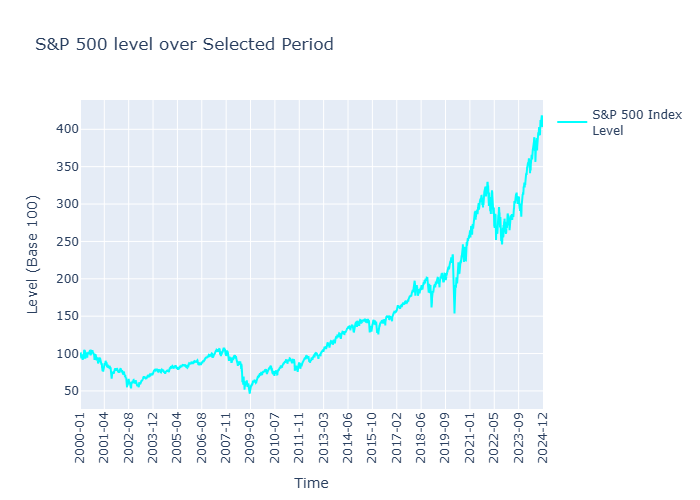

In [90]:
fig = dta.make_level_figure(
    df=sp500_interday,
    cols_of_interest=level_cols,
    reindex=True,
    x_tick_label_mode="year_month",
    title="Comparison of Levels",
    figure_title="S&P 500 level over Selected Period",
    fig_height=800
)


fig.show("png")


## 1. Buying and holding the SPDR S&P 500 ETF (SPY) over the period

## 2. Baseline *inter*-day volatility control strategy

### Import the forecasted quantiles data and merge the quantiles with the S&P 500 returns data

In [91]:
# Load, clean, and merge the S&P 500 returns with BJQTS quantile forecasts.
# Paths are resolved from the notebook cwd first, then from the project root.
merger = st.QuantileForecastsMerger(
    returns_path="data/intermediate_input/sp500_interday_returns.xlsx",
    mat_path="data/intermediate_input/q_minus_all_BJSAV_5_norm_SP500.mat",
    mat_key="q_minus_all_select",
    date_format="%d-%b-%Y",
    drop_zero=True,
    burn_in=2520,
    label=False,
)

merged_returns = merger.run()
# after the merger class instance is run, we have updated merger.returns and the quantile forecasts
cleaned_returns = merger.returns
quantile_forecasts_df = merger.quantile_forecasts_df

In [92]:
merged_returns

,time,return,q_1,q_2,q_3,q_4,q_5,q_6,q_7,q_8
0,2010-01-13,0.008291,-0.000766,-0.001569,-0.002505,-0.003777,-0.005325,-0.006875,-0.008647,-0.011634
1,2010-01-14,0.002424,-0.000841,-0.001709,-0.002698,-0.004041,-0.005679,-0.007323,-0.009215,-0.012363
2,2010-01-15,-0.010882,-0.000795,-0.001609,-0.002544,-0.003845,-0.005431,-0.007004,-0.008828,-0.011878
3,2010-01-19,0.012422,-0.000934,-0.001876,-0.002928,-0.004360,-0.006114,-0.007875,-0.009918,-0.013269
4,2010-01-20,-0.010654,-0.001061,-0.002120,-0.003277,-0.004836,-0.006750,-0.008690,-0.010937,-0.014573
...,...,...,...,...,...,...,...,...,...,...
3761,2024-12-24,0.010982,-0.001017,-0.002016,-0.003111,-0.004428,-0.006024,-0.008001,-0.010616,-0.015215
3762,2024-12-26,-0.000406,-0.001057,-0.002096,-0.003236,-0.004605,-0.006263,-0.008314,-0.011021,-0.015769
3763,2024-12-27,-0.011117,-0.000945,-0.001866,-0.002878,-0.004109,-0.005627,-0.007516,-0.010025,-0.014490
3764,2024-12-30,-0.010760,-0.001022,-0.002022,-0.003120,-0.004448,-0.006070,-0.008082,-0.010742,-0.015439


### Exploratory analysis of the forecast quantiles

#### Select the relevant columns and groupings

In [93]:
# Specify the correct columns that we want to plot:
# all the columns that have 'level' in their name

# rename the return column to spx_return for clarity later
merged_returns = merged_returns.rename(columns={'return': 'spx_return'})

quantile_cols = [col for col in merged_returns.columns if 'q' in col]

benchmark_cols = [col for col in merged_returns.columns if 'return' in col]

selected_cols =  benchmark_cols + quantile_cols

selected_cols

['spx_return', 'q_1', 'q_2', 'q_3', 'q_4', 'q_5', 'q_6', 'q_7', 'q_8']

### Generate the plot

#### Dash app version (will not render in github)

In [94]:
# reimport to refresh dynamics
importlib.reload(dta)

<module 'src.stats_utils.dash_timeseries_app' from 'c:\\Users\\danie\\OneDrive\\Desktop\\Github_Pages\\Risk-Control-Using-a-Bayesian-Joint-Quantile-Time-Series-Model-For-Asset-Returns\\src\\stats_utils\\dash_timeseries_app.py'>

In [95]:
# enter those parameters into the dash app that creates the plot
cfg = dta.LevelAppConfig(
    cols_of_interest=selected_cols,
    reindex=False,
    x_tick_label_mode="year_month",
    title="Comparison of Returns and Quantile Forecasts",
    figure_title="Comparison of S&P 500 returns and quantile forecasts over selected period",
    fig_height=800,
    port=8051,
    colour_groups=[
        {
            "cols": ["spx_return"],
            "colour": "black",
            "opacity": 0.30,
            "name": "benchmark",
        },
        {
            "cols": quantile_cols,
            "start": "cyan",
            "end": "purple",
            "opacity": 0.95,
            "name": "quantiles",
        },
    ],
)

# run the app (produce the plot)
dash_app = dta.LevelDashApp(merged_returns, cfg)
dash_app.run(debug=True)

#### PNG Version (Will display in Github version of notebook)

In [96]:
# keep all the same parameters as before, simply change the figure title to reflect that this is the COVID period
cfg_covid = replace(
    cfg,
    figure_title="Comparison of S&P 500 returns and quantile forecasts over COVID period"
)

fig = dta.make_level_figure(
    merged_returns,
    cfg=cfg_covid,
    time_window=("2019-05-31", "2021-05-31"),
)

fig.show()

### Use the forecast quantiles to adjust market exposure, and calculate returns

### Calculate Target Weights Based on Forecast Quantiles

Consider a simple representative portfolio with some weight in a market index and some weight in cash. We back-test the performance of index strategies where the index portfolio is rebalanced daily, and the weights are adjusted based on the forecasted quantiles of returns.

For comparability to volatility targeting, we similarly dynamically adjust the weights in the market index so as to maintain target forecasted quantiles. When the forecasted lower/left tail quantiles of returns on the carrying value of the portfolio are below the target/are more negative, we reduce the weights in the market index until the forecasted quantile of returns returns to target. Likewise, when the forecasted upper/right tail quantiles are above the target, we increase the weights in the market index.

By setting a target step-ahead quantile at probability level p% to not fall below a certain level, r%, we effectively aim for the portfolio to have no more than a p% probability of seeing a drawdown of k% or more over the next step-ahead period. This can then aggregate to a longer period, such as over the next quarter or year. For reference, if we set p = 5.56%, and r = 0.63%, then we are aiming for the portfolio to have no more than a 5.56% probability of seeing a drawdown of 0.63% or more over the next step-ahead period, and in turn, no more than a 5.56% probability of seeing a drawdown of 5% or more over the next quarter.

### Calculate 'Actual' Weights to Reflect Trading Delays

In the above, we created a index_weight column that is the target weight column shifted by one row this is to reflect a 1-day trading delay (we only know the target weight at the beginning of the day that follows the last day of the estimation window, because only then do we know the confirmed closing price of the last day).

For liquidity reasons, we only trade once a day, at the end of the day, and so even though we know the target weight at the beginning of the day, we only trade at the end of that day.

In [98]:
importlib.reload(st)

<module 'src.stats_utils.strategies' from 'c:\\Users\\danie\\OneDrive\\Desktop\\Github_Pages\\Risk-Control-Using-a-Bayesian-Joint-Quantile-Time-Series-Model-For-Asset-Returns\\src\\stats_utils\\strategies.py'>

In [99]:
strategy = st.QuantileRiskControlStrategy(r=0.0063, spec=2, q_level=8)
out = strategy.run(merged_returns)### Start with one specification, then test multiple specifications 

this is done both to optimise as well as to test stability

### Calculate Total Returns

Note that this is done over a specified window of one's choosing, by default, we zoom in on the GFC period, but this can be changed by modifying the `start_date` and `end_date` variables.

In [100]:
# Multiple specifications
strategy_grid = st.QuantileRiskControlGrid(
r_list=[0.007, 0.008, 0.01, 0.012],
q_level_list=[7, 8],
spec_list=[2]
)
grid_df = strategy_grid.run(merged_returns)

In [101]:
grid_df

,time,spx_return,q_1,q_2,q_3,q_4,q_5,q_6,q_7,q_8,...,risk_control_return__q_7_target_at_1.00%_spec_2,target_weight__q_8_target_at_1.00%_spec_2,actual_weight__q_8_target_at_1.00%_spec_2,risk_control_return__q_8_target_at_1.00%_spec_2,target_weight__q_7_target_at_1.20%_spec_2,actual_weight__q_7_target_at_1.20%_spec_2,risk_control_return__q_7_target_at_1.20%_spec_2,target_weight__q_8_target_at_1.20%_spec_2,actual_weight__q_8_target_at_1.20%_spec_2,risk_control_return__q_8_target_at_1.20%_spec_2
0,2010-01-13,0.008291,-0.000766,-0.001569,-0.002505,-0.003777,-0.005325,-0.006875,-0.008647,-0.011634,...,NaN,0.859525,NaN,NaN,1.0,NaN,NaN,1.000000,NaN,NaN
1,2010-01-14,0.002424,-0.000841,-0.001709,-0.002698,-0.004041,-0.005679,-0.007323,-0.009215,-0.012363,...,0.002424,0.808896,0.859525,0.002083,1.0,1.0,0.002424,0.970675,1.000000,0.002424
2,2010-01-15,-0.010882,-0.000795,-0.001609,-0.002544,-0.003845,-0.005431,-0.007004,-0.008828,-0.011878,...,-0.010882,0.841890,0.808896,-0.008803,1.0,1.0,-0.010882,1.000000,0.970675,-0.010563
3,2010-01-19,0.012422,-0.000934,-0.001876,-0.002928,-0.004360,-0.006114,-0.007875,-0.009918,-0.013269,...,0.012422,0.753662,0.841890,0.010458,1.0,1.0,0.012422,0.904395,1.000000,0.012422
4,2010-01-20,-0.010654,-0.001061,-0.002120,-0.003277,-0.004836,-0.006750,-0.008690,-0.010937,-0.014573,...,-0.010654,0.686181,0.753662,-0.008030,1.0,1.0,-0.010654,0.823417,0.904395,-0.009636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3761,2024-12-24,0.010982,-0.001017,-0.002016,-0.003111,-0.004428,-0.006024,-0.008001,-0.010616,-0.015215,...,0.010190,0.657229,0.649478,0.007133,1.0,1.0,0.010982,0.788675,0.779374,0.008559
3762,2024-12-26,-0.000406,-0.001057,-0.002096,-0.003236,-0.004605,-0.006263,-0.008314,-0.011021,-0.015769,...,-0.000382,0.634172,0.657229,-0.000267,1.0,1.0,-0.000406,0.761007,0.788675,-0.000320
3763,2024-12-27,-0.011117,-0.000945,-0.001866,-0.002878,-0.004109,-0.005627,-0.007516,-0.010025,-0.014490,...,-0.010087,0.690112,0.634172,-0.007050,1.0,1.0,-0.011117,0.828134,0.761007,-0.008460
3764,2024-12-30,-0.010760,-0.001022,-0.002022,-0.003120,-0.004448,-0.006070,-0.008082,-0.010742,-0.015439,...,-0.010733,0.647717,0.690112,-0.007425,1.0,1.0,-0.010760,0.777261,0.828134,-0.008910


## Compare Performance of Different Srategies

#### Iteratively Add to a Dataframe to Store Comparative Results

def plot_w(weights_plot_df, plot_name=None):
    """
    Create a ggplot object for target and index weights over time.

    Args:
        weights_plot_df (pd.DataFrame): DataFrame in long format with columns ['time', 'time_label', 'weight_type', 'weight_value'].

    Returns:
        plotnine.ggplot.ggplot: The ggplot object (not displayed).
    """
    # Generate x-axis breaks and labels for clear date ticks
    time_breaks, time_labels = gen_x_labels(weights_plot_df)

    if plot_name:
        plot_title = plot_name
    else:
        plot_title = "Target and Actual Weights in Market Index Over Time"

    # Create the plot using plotnine (ggplot-style)
    plot_w_targ = (
        # Set up the basic plot with aesthetics: x=time, y=weight_value, color/alpha by weight_type
        ggplot(weights_plot_df, aes(x='time', y='weight_value', color='weight_type', alpha='weight_type')) +
        # Draw lines for each weight_type
        geom_line(size=1) +
        # Set plot and axis labels
        labs(
            title=plot_title,
            x='Time',
            y='Weight',
            color='Weight Type'
        ) +
        # Set transparency for each weight_type
        scale_alpha_manual(values=weights_alpha_map) +
        # Set x-axis breaks and labels for dates
        scale_x_date(breaks=time_breaks, labels=time_labels) +
        # Set colors for each weight_type and legend labels
        scale_color_manual(values=weights_color_map, labels=weights_label_map) +
        # Format y-axis to show two decimal places
        scale_y_continuous(labels=lambda l: [f"{v:.2f}" for v in l]) +
        # Customize theme: rotate x labels, center title, set figure size
        theme(
            axis_text_x=element_text(rotation=90, ha='center'),
            plot_title=element_text(ha='center'),
            figure_size=(8, 3)
        ) +
        # Remove unwanted guides from legend (hide alpha legend)
        guides(alpha=False)
    )
    return plot_w_targ


## Compare to S&P 500 Intraday Indices

### Import and clean the intraday indices data

In [102]:
cleaner = st.IntradayIndexLevelsCleaner()
intraday_index_levels = cleaner.run()

#### Add log return and cumulative return columns for these indices

In [103]:
# run an instance of the ReturnsCalculator class from the returns.py module to compute log returns
calc = rt.ReturnsCalculator(rt.ReturnsConfig(return_kind="log", inplace=False))

# run the transform method of the ReturnsCalculator instance to compute the returns
intraday_index_levels_v2 = calc.transform(intraday_index_levels)

### Combine the returns of the indices with our own strategies

In [104]:
# extract only the returns columns from grid_df as well as the time column for merging with the index returns
strategies_returns = grid_df.filter(regex="return|time")

#extract only the returns columns from intraday_index_levels_v2 as well as the time column for merging
intraday_index_returns = intraday_index_levels_v2.filter(regex="period_return|time")

# outer merge the two datasets together on the time column
merged_strat_returns = pd.merge(
    strategies_returns,
    intraday_index_returns,
    left_on="time",
    right_on="time",
    how="outer"
)


In [105]:
merged_strat_returns

,time,spx_return,risk_control_return__q_7_target_at_0.70%_spec_2,risk_control_return__q_8_target_at_0.70%_spec_2,risk_control_return__q_7_target_at_0.80%_spec_2,risk_control_return__q_8_target_at_0.80%_spec_2,risk_control_return__q_7_target_at_1.00%_spec_2,risk_control_return__q_8_target_at_1.00%_spec_2,risk_control_return__q_7_target_at_1.20%_spec_2,risk_control_return__q_8_target_at_1.20%_spec_2,sp_500_dynamic_intraday_tca_index_usd_er_period_return,sp_500_futures_index_er_period_return,sp_500_futures_12%_intraday_edge_growth_tca_usd_er_period_return,sp_multi-asset_5%_intraday_edge_macro_tca_index_usd_er_period_return,sp_500_futures_7%_intraday_edge_volatility_tca_index__usd_er_period_return
0,2010-01-13,0.008291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-14,0.002424,0.001962,0.001458,0.002242,0.001666,0.002424,0.002083,0.002424,0.002424,NaN,NaN,NaN,NaN,NaN
2,2010-01-15,-0.010882,-0.008267,-0.006162,-0.009448,-0.007042,-0.010882,-0.008803,-0.010882,-0.010563,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,0.012422,0.009849,0.007321,0.011256,0.008366,0.012422,0.010458,0.012422,0.012422,NaN,NaN,NaN,NaN,NaN
4,2010-01-20,-0.010654,-0.007520,-0.005621,-0.008594,-0.006424,-0.010654,-0.008030,-0.010654,-0.009636,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4027,2026-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005565,0.002210,0.003069,-0.002237,0.002065
4028,2026-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000269,-0.000714,0.000212,-0.004856,-0.000639
4029,2026-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.039788,-0.021341,-0.021308,0.001789,-0.013655
4030,2026-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015623,0.011712,0.008793,0.005212,0.004771


## EDA of returns data

### Plot setup

In [107]:
# Specify the correct columns that we want to plot:
# all the columns that have 'period_return' in their name

# 1) Choose return columns
returns_cols = [col for col in merged_strat_returns.columns if "return" in col]

# 2) Build groups
benchmark_cols = ["spx_return"]

risk_control_cols = [
    c for c in returns_cols
    if c.startswith("risk_control_return")
]

sp_return_cols = [
    c for c in returns_cols
    if c.startswith("sp_") and c != "spx_return"
]

risk_control_cols, sp_return_cols

(['risk_control_return__q_7_target_at_0.70%_spec_2',
  'risk_control_return__q_8_target_at_0.70%_spec_2',
  'risk_control_return__q_7_target_at_0.80%_spec_2',
  'risk_control_return__q_8_target_at_0.80%_spec_2',
  'risk_control_return__q_7_target_at_1.00%_spec_2',
  'risk_control_return__q_8_target_at_1.00%_spec_2',
  'risk_control_return__q_7_target_at_1.20%_spec_2',
  'risk_control_return__q_8_target_at_1.20%_spec_2'],
 ['sp_500_dynamic_intraday_tca_index_usd_er_period_return',
  'sp_500_futures_index_er_period_return',
  'sp_500_futures_12%_intraday_edge_growth_tca_usd_er_period_return',
  'sp_multi-asset_5%_intraday_edge_macro_tca_index_usd_er_period_return',
  'sp_500_futures_7%_intraday_edge_volatility_tca_index__usd_er_period_return'])

### Plot display

In [ ]:
# hardcode re-import of the visualisation dash app if needed
#import src.stats_utils.dash_timeseries_app as dta
#importlib.reload(dta)

#### Dash app plot (does not render on github)

In [110]:
# enter those parameters into the dash app that creates the plot
cfg = dta.LevelAppConfig(
    cols_of_interest=returns_cols,
    reindex=False,
    x_tick_label_mode="year_month",
    title="Comparison of Index Returns",
    figure_title="Index Returns over Selected Period",
    fig_height=800,
    port=8054,
    colour_groups=[
        {
            "cols": benchmark_cols,
            "colour": "black",
            "opacity": 0.30,
            "name": "benchmark",
        },
        {
            "cols": risk_control_cols,
            "start": "cyan",
            "end": "magenta",
            "opacity": 0.8,
            "name": "risk_control",
        },
        {
            "cols": sp_return_cols,
            "start": "#FFB347",  # warm/orangey yellow
            "end": "#D62728",    # red
            "opacity": 0.6,
            "name": "sp_returns",
        },
    ],
    auto_colour_map=True,  # fallback for any "other_cols"
)

# run the app (produce the plot)
dash_app = dta.LevelDashApp(merged_strat_returns, cfg)
dash_app.run(
    debug=False
)

#### Hardcode png version of figure (displays in github) for COVID period

In [111]:
cfg_covid = replace(
    cfg,
    title="Comparison of Index Returns (COVID Window)",
    figure_title="Index Returns over COVID Period",
)

fig = dta.make_level_figure(
    merged_strat_returns,
    cfg=cfg_covid,
    time_window=("2019-05-31", "2021-05-31"),
)

fig.show()

## Compare Performance of Different Srategies

#### Create a Function to Save the Performance Summary Statistics to Excel Nicely

In [ ]:
def save_with_bold_highlights(summary_stats, filename):
    # Identify metric pairs (assume every two columns after the first two are a pair)
    cols = summary_stats.columns.tolist()
    pairs = [(cols[i], cols[i+1]) for i in range(2, len(cols), 2)]
    volatility_keywords = ['volatility']
    sharpe_keywords = ['sharpe']

    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        summary_stats.to_excel(writer, index=False)
        workbook  = writer.book
        worksheet = writer.sheets['Sheet1']
        bold = workbook.add_format({'bold': True})

        for row in range(1, len(summary_stats)+1):  # +1 for header
            for col1, col2 in pairs:
                idx1 = cols.index(col1)
                idx2 = cols.index(col2)
                val1 = summary_stats.iloc[row-1, idx1]
                val2 = summary_stats.iloc[row-1, idx2]
                metric = col1.lower()

                # For volatility, lower is better
                if any(key in metric for key in volatility_keywords):
                    if val1 < val2:
                        worksheet.write(row, idx1, val1, bold)
                    elif val2 < val1:
                        worksheet.write(row, idx2, val2, bold)
                # For Sharpe, ignore if both negative
                elif any(key in metric for key in sharpe_keywords):
                    if val1 >= 0 and val1 > val2:
                        worksheet.write(row, idx1, val1, bold)
                    elif val2 >= 0 and val2 > val1:
                        worksheet.write(row, idx2, val2, bold)
                # For all other metrics, higher is better
                else:
                    if val1 > val2:
                        worksheet.write(row, idx1, val1, bold)
                    elif val2 > val1:
                        worksheet.write(row, idx2, val2, bold)

        # writer.save()

#### Create a Function to Calculate Performance Metrics

In [ ]:
# hardcode backup for reloading the performance module
#importlib.reload(pm)
# from src.stats_utils.performance import PerformanceSummary

In [52]:
importlib.reload(pm)

<module 'src.stats_utils.performance' from 'c:\\Users\\danie\\OneDrive\\Desktop\\Github_Pages\\Risk-Control-Using-a-Bayesian-Joint-Quantile-Time-Series-Model-For-Asset-Returns\\src\\stats_utils\\performance.py'>

In [112]:
# set up the configuration for the performance summary
ps = pm.PerformanceSummary(
    merged_strat_returns,
    returns_cols,
    kind="log",
    annualise=["windows", "rolling_lookbacks"],
    resample_freq=["YE", "Q"],
    rolling_lookback_years=[5],
    rolling_anchor_freq="YE",
    align_end_dates=True,
    include_stress_windows=True,
    include_vol=True,
    include_drawdown=True,
    periods_per_year=252,
    )
# run the performance summary calculation
strategies_performance_summary_df = ps.run()

# inspect the summary dataframe
strategies_performance_summary_df

,Period,Start Date,End Date,Spx Return,Risk Control Return Q 7 Target At 0.70% Spec 2,Risk Control Return Q 8 Target At 0.70% Spec 2,Risk Control Return Q 7 Target At 0.80% Spec 2,Risk Control Return Q 8 Target At 0.80% Spec 2,Risk Control Return Q 7 Target At 1.00% Spec 2,Risk Control Return Q 8 Target At 1.00% Spec 2,...,Risk Control Return Q 8 Target At 0.80% Spec 2 Max Drawdown,Risk Control Return Q 7 Target At 1.00% Spec 2 Max Drawdown,Risk Control Return Q 8 Target At 1.00% Spec 2 Max Drawdown,Risk Control Return Q 7 Target At 1.20% Spec 2 Max Drawdown,Risk Control Return Q 8 Target At 1.20% Spec 2 Max Drawdown,Sp 500 Dynamic Intraday Tca Index Usd Er Period Return Max Drawdown,Sp 500 Futures Index Er Period Return Max Drawdown,Sp 500 Futures 12% Intraday Edge Growth Tca Usd Er Period Return Max Drawdown,Sp Multi-Asset 5% Intraday Edge Macro Tca Index Usd Er Period Return Max Drawdown,Sp 500 Futures 7% Intraday Edge Volatility Tca Index Usd Er Period Return Max Drawdown
0,YTD,2024-01-02,2024-12-31,0.2331,0.1524,0.1028,0.1780,0.1183,0.2069,0.1499,...,-0.0475,-0.0780,-0.0591,-0.0842,-0.0694,-0.0958,-0.0874,-0.0598,-0.0308,-0.0330
1,Last 1 Years,2024-01-02,2024-12-31,0.2340,0.1529,0.1032,0.1786,0.1187,0.2077,0.1505,...,-0.0475,-0.0780,-0.0591,-0.0842,-0.0694,-0.0958,-0.0874,-0.0598,-0.0308,-0.0330
2,Last 3 Years,2021-12-31,2024-12-31,0.0717,0.0458,0.0319,0.0530,0.0365,0.0610,0.0459,...,-0.1218,-0.2124,-0.1498,-0.2333,-0.1770,-0.1856,-0.2522,-0.1605,-0.0568,-0.1011
3,Last 5 Years,2019-12-31,2024-12-31,0.1279,0.0743,0.0494,0.0863,0.0567,0.1050,0.0716,...,-0.1229,-0.2124,-0.1512,-0.2333,-0.1770,-0.2111,-0.3415,-0.1615,-0.0568,-0.1027
4,Last 10 Years,2014-12-31,2024-12-31,0.1095,0.0597,0.0405,0.0689,0.0464,0.0848,0.0588,...,-0.1229,-0.2124,-0.1512,-0.2333,-0.1770,-0.2111,-0.3415,-0.1615,-0.0605,-0.1027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,2010Q4,2010-10-01,2010-12-31,0.1020,0.0689,0.0507,0.0791,0.0582,0.0902,0.0732,...,-0.0220,-0.0366,-0.0274,-0.0388,-0.0328,NaN,NaN,NaN,NaN,NaN
93,2010,2010-01-01,2010-12-31,0.1069,0.0776,0.0566,0.0892,0.0650,0.0934,0.0819,...,-0.0685,-0.1105,-0.0848,-0.1274,-0.1009,NaN,NaN,NaN,NaN,NaN
94,2010Q3,2010-07-01,2010-09-30,0.1072,0.0411,0.0311,0.0471,0.0356,0.0593,0.0447,...,-0.0341,-0.0562,-0.0424,-0.0670,-0.0507,NaN,NaN,NaN,NaN,NaN
95,2010Q2,2010-04-01,2010-06-30,-0.1186,-0.0464,-0.0355,-0.0529,-0.0405,-0.0703,-0.0504,...,-0.0659,-0.1064,-0.0817,-0.1226,-0.0972,NaN,NaN,NaN,NaN,NaN


#### Save out the file to excel

In [113]:
ps.save_to_excel(filepath = "../data/output/strategies_performance_summary.xlsx")

## Compare performance during specific periods in the history

#### First, convert returns to levels, indexed to 100 for ease of comparison

In [114]:
lvl = pm.ReturnsToLevels(
    merged_strat_returns,
    returns_cols,
    kind="log",                 # or "simple"
    time_col="time",
    keep_time_col=True,         # returns DataFrame with time column for plotting
    align_common_calendar=True, # keeps only timestamps where all series exist
)

levels_df = lvl.run()
# levels_df now has same return columns, but as level series rebased to 100
# plus time column (if keep_time_col=True)

In [115]:
levels_df

,time,spx_return,risk_control_return__q_7_target_at_0.70%_spec_2,risk_control_return__q_8_target_at_0.70%_spec_2,risk_control_return__q_7_target_at_0.80%_spec_2,risk_control_return__q_8_target_at_0.80%_spec_2,risk_control_return__q_7_target_at_1.00%_spec_2,risk_control_return__q_8_target_at_1.00%_spec_2,risk_control_return__q_7_target_at_1.20%_spec_2,risk_control_return__q_8_target_at_1.20%_spec_2,sp_500_dynamic_intraday_tca_index_usd_er_period_return,sp_500_futures_index_er_period_return,sp_500_futures_12%_intraday_edge_growth_tca_usd_er_period_return,sp_multi-asset_5%_intraday_edge_macro_tca_index_usd_er_period_return,sp_500_futures_7%_intraday_edge_volatility_tca_index__usd_er_period_return
0,2016-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,2016-01-05,100.201226,100.100231,100.069011,100.114558,100.078874,100.143218,100.098602,100.171886,100.118334,100.213719,100.131712,100.265063,100.150799,100.060533
2,2016-01-06,98.887045,99.498723,99.651703,99.427318,99.602046,99.284660,99.502805,99.142208,99.403663,99.369021,98.855117,99.357733,100.060320,99.626715
3,2016-01-07,96.543380,98.296977,98.822622,98.056067,98.655561,97.576017,98.322285,97.098318,97.990135,98.066355,96.210740,98.399429,99.879361,98.960856
4,2016-01-08,95.497004,97.789810,98.469892,97.478082,98.253225,96.857603,97.821320,96.241074,97.391313,97.445553,95.146910,98.012030,99.728561,98.587571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,2024-12-24,300.102352,194.916477,157.756116,215.194983,168.372030,250.394142,192.617953,272.499123,220.764146,325.977982,282.586541,304.936489,193.680446,193.886199
2259,2024-12-26,299.980623,194.864342,157.726673,215.129203,168.336118,250.298471,192.566599,272.388590,220.693519,326.507332,282.454747,305.374704,193.931731,193.886199
2260,2024-12-27,296.664116,193.493276,156.950178,213.400188,167.389336,247.786411,191.213724,269.377134,218.834253,322.486306,279.291691,303.132674,193.600035,193.432203
2261,2024-12-30,293.489213,192.044960,156.136504,211.575657,166.397939,245.141088,189.799147,266.494257,216.892999,320.144949,276.128636,303.407832,193.037156,193.210250


### COVID period performance

#### Plot setup

In [118]:
# Specify the correct columns that we want to plot:
# all the columns that have 'period_return' in their name
# same column names as used in previous analysis

benchmark_cols, risk_control_cols, sp_return_cols

(['spx_return'],
 ['risk_control_return__q_7_target_at_0.70%_spec_2',
  'risk_control_return__q_8_target_at_0.70%_spec_2',
  'risk_control_return__q_7_target_at_0.80%_spec_2',
  'risk_control_return__q_8_target_at_0.80%_spec_2',
  'risk_control_return__q_7_target_at_1.00%_spec_2',
  'risk_control_return__q_8_target_at_1.00%_spec_2',
  'risk_control_return__q_7_target_at_1.20%_spec_2',
  'risk_control_return__q_8_target_at_1.20%_spec_2'],
 ['sp_500_dynamic_intraday_tca_index_usd_er_period_return',
  'sp_500_futures_index_er_period_return',
  'sp_500_futures_12%_intraday_edge_growth_tca_usd_er_period_return',
  'sp_multi-asset_5%_intraday_edge_macro_tca_index_usd_er_period_return',
  'sp_500_futures_7%_intraday_edge_volatility_tca_index__usd_er_period_return'])

#### Plot display

In [123]:
# enter those parameters into the dash app that creates the plot
cfg = dta.LevelAppConfig(
    cols_of_interest=level_cols,
    reindex=True,
    x_tick_label_mode="year_month",
    title="Comparison of Index Levels",
    figure_title="Index Levels over Selected Period",
    fig_height=800,
    port=8055,
    colour_groups=[
        {
            "cols": benchmark_cols,
            "colour": "black",
            "opacity": 1.0,
            "name": "benchmark",
        },
        {
            "cols": risk_control_cols,
            "start": "cyan",
            "end": "magenta",
            "opacity": 0.95,
            "name": "risk_control",
        },
        {
            "cols": sp_return_cols,
            "start": "#FFB347",  # warm/orangey yellow
            "end": "#D62728",    # red
            "opacity": 0.85,
            "name": "sp_returns",
        },
    ],
    auto_colour_map=True,  # fallback for any remaining cols
)

# run the app (produce the plot)
dash_app = dta.LevelDashApp(levels_df, cfg)
dash_app.run(
    debug=False
)

#### Hardcode png version of figure (displays in github) for COVID period

In [124]:
cfg_covid = replace(
    cfg,
    title="Comparison of Index Levels (COVID Window)",
    figure_title="Index Levels over COVID Period",
)

fig = dta.make_level_figure(
    levels_df,
    cfg=cfg_covid,
    time_window=("2019-05-31", "2021-05-31"),
)

fig.show()

#### During COVID

##### Daily Returns and Forecasted Quantiles with Total Returns

##### Weights

#### During the Whole Window of Data

##### Total Returns

##### Daily Returns and Forecasted Quantiles

##### Weights

#### During the 2021 Rate Hikes

##### Daily Returns and Forecasted Quantiles with Total Returns

##### Weights